In [1]:
# General purpose
import numpy as np
import time
from pathlib import Path
from glob import glob

# Segmentation
from cellpose import models, core, io, transforms

# Quick plotting
from matplotlib import pyplot as plt
from skimage.color import label2rgb

import torch

### Uncomment the one corresponding to your speficications
## macOS
device = torch.device("mps")

## cuda
#device = torch.device("gpu")

In [4]:
# define parameters
params = {'rescale': None, # upscale or downscale your images, None = no rescaling 

          'cellprob_threshold': 0, # erode or dilate masks with higher or lower values 

          'flow_threshold': 0.4, # default is .4, but only needed if there are spurious masks to clean up; slows down output

          'niter': 2000, # None lets Cellpose calculate # of Euler iterations (usually <20) but you can tune it for over/under segmentation 

         }

model_path = '/Users/reyesmatte/models/CellposeSAM/cpSAM_FM4_raw'
model = models.CellposeModel(pretrained_model=model_path, device=device)

In [5]:
im_path = '/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig2/Benchmarking_data/Raw/Images/*.tif'

files = sorted(glob(im_path))[:5]

print(f'\nnumber of images: {len(files)}')

imgs = [transforms.normalize99(io.imread(f)) for f in files]


number of images: 5


In [6]:
tic = time.time() 

masks, flows, styles = model.eval([img for img in imgs],**params)

net_time = time.time() - tic

print('total segmentation time: {}s'.format(net_time))

total segmentation time: 448.68068408966064s


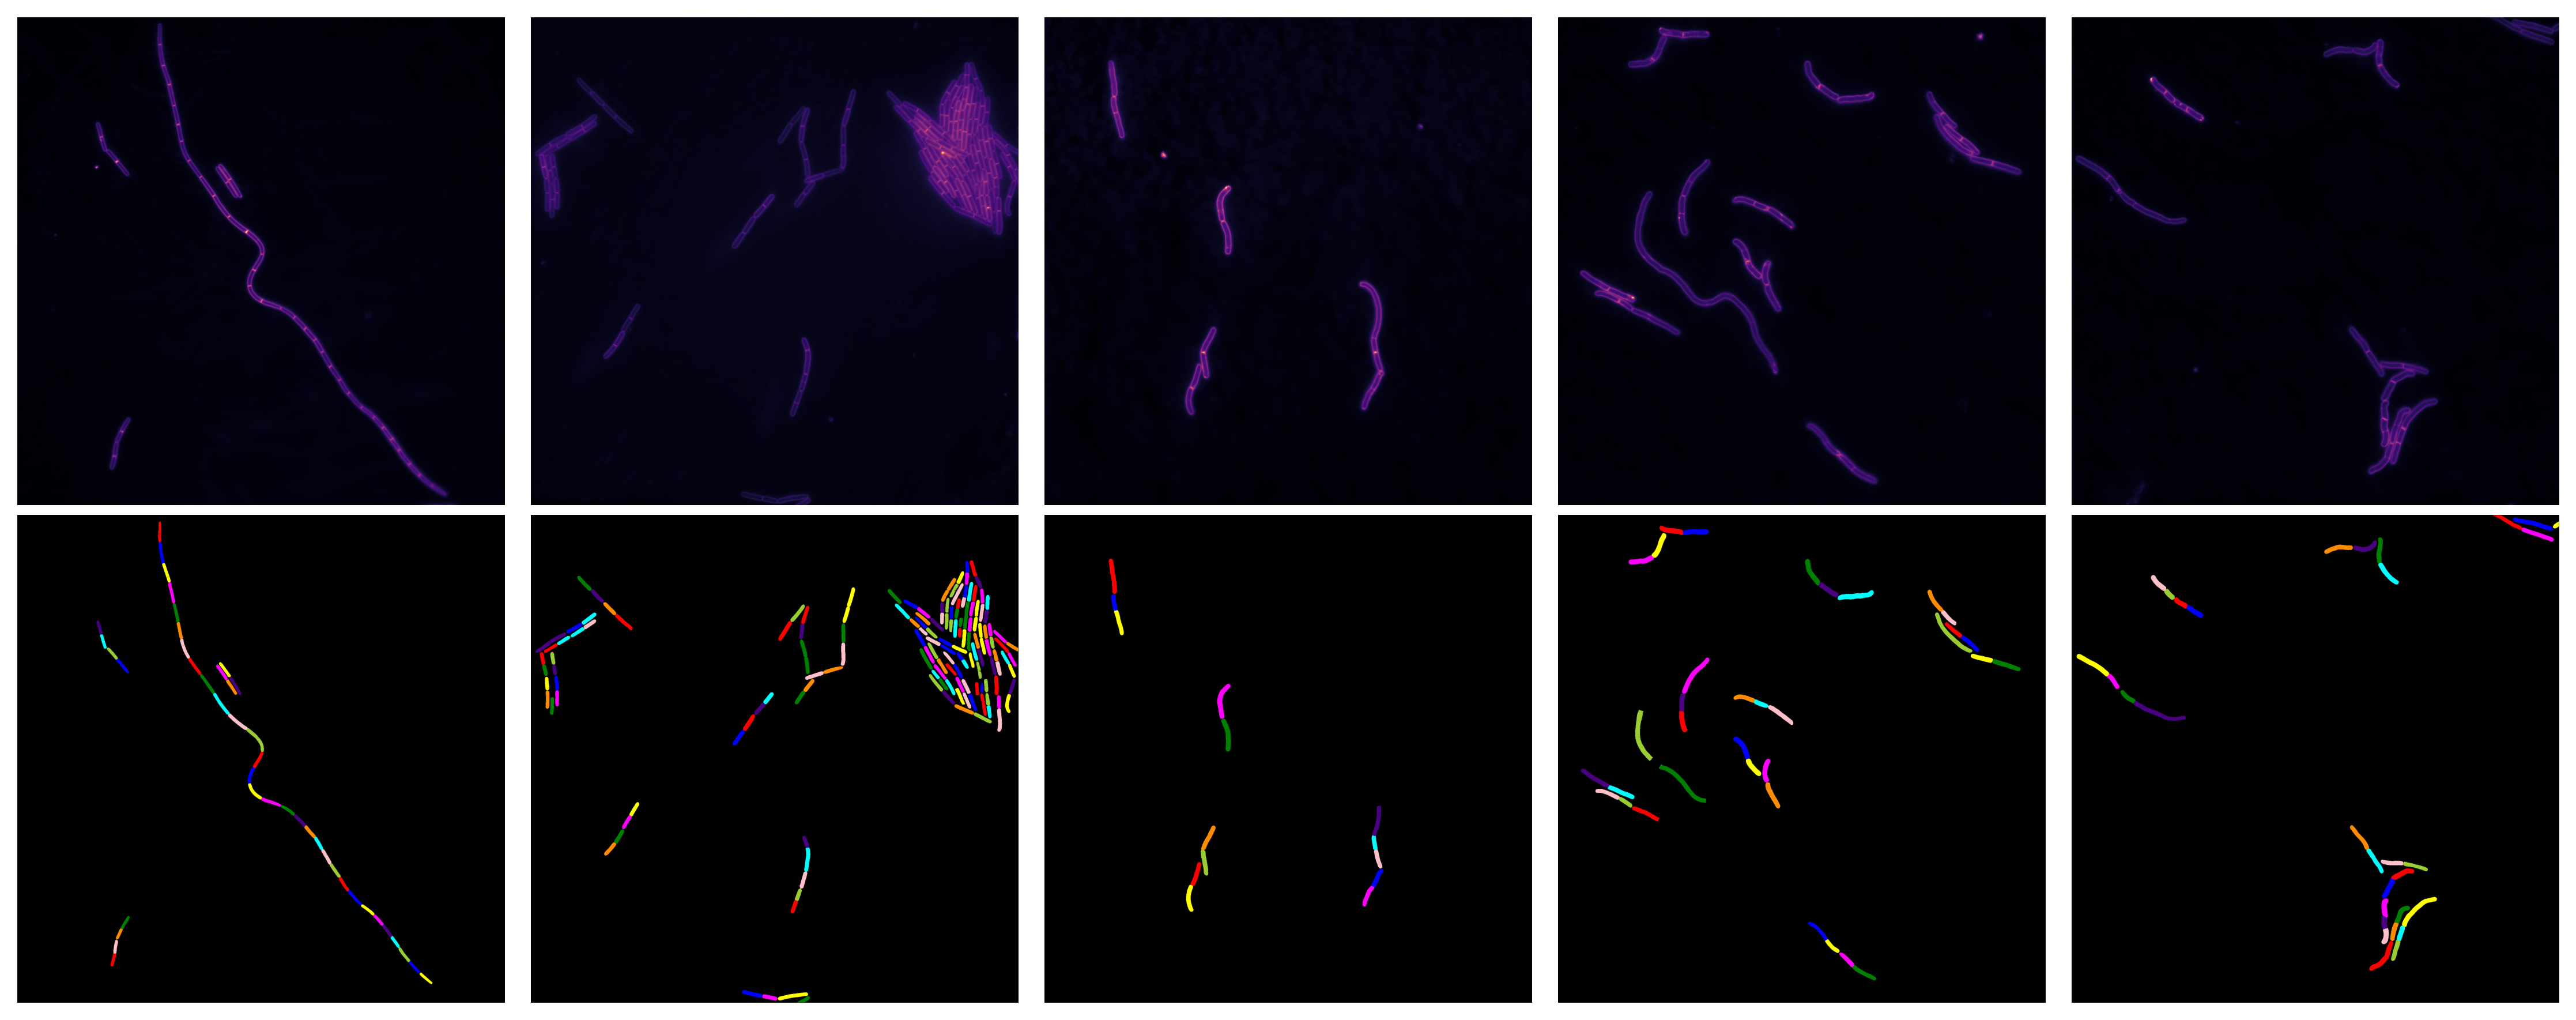

In [7]:
fig,ax = plt.subplots(dpi=300,figsize=(15,6),ncols=5,nrows=2)

for i in range(len(files)):

    ax[0,i].imshow(imgs[i],cmap='magma')
    ax[0,i].axis('off')

    ax[1,i].imshow(label2rgb(masks[i]))
    ax[1,i].axis('off')

fig.tight_layout()

In [5]:
# Save masks and outlines

io.save_masks(imgs, masks, flows, files, 

              png=True,

              tif=False, # whether to use PNG or TIF format

              suffix='', # suffix to add to files if needed 

              save_flows=False, # saves both RGB depiction as *_flows.png and the raw components as *_dP.tif

              save_outlines=False, # save outline images 

              dir_above=0, # save output in the image directory or in the directory above (at the level of the image directory)

              in_folders=False, # save output in folders (recommended)

              save_txt=False, # txt file for outlines in imageJ

              save_plot=False, # plot file
              
              save_ncolor=False) # save ncolor version of masks for visualization and editing 
